In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("/content/drive/MyDrive/Datasets/WA_Fn-UseC_-Telco-Customer-Churn.csv")

#**PHASE1**:Understanding the **DATA**

In [6]:
print(df.shape)
print(df.dtypes)
print(df.head())
df.info()

(7043, 21)
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45    

In [7]:
#We want the total charges to not be object, we want them to be numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(df['TotalCharges'].isnull().sum())

11


Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


/tmp/ipykernel_2249/72025802.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette=['#2ecc71', '#e74c3c'])


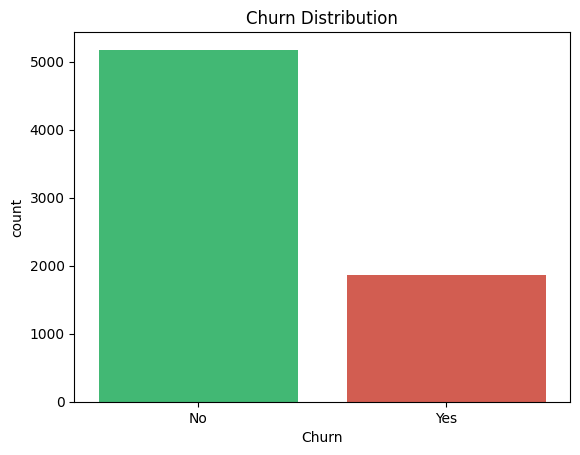

In [8]:
churn_counts = df['Churn'].value_counts()
print(churn_counts)
print(df['Churn'].value_counts(normalize=True)*100)

#Plot
sns.countplot(x='Churn', data=df, palette=['#2ecc71', '#e74c3c'])
plt.title("Churn Distribution")
plt.show()

In [9]:
categorical = df.select_dtypes(include='object').columns.tolist()
numerical = df.select_dtypes(include=['int64','float64']).columns.tolist()

print("Categorical: ", categorical)
print("Numerical: ", numerical)

Categorical:  ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']
Numerical:  ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


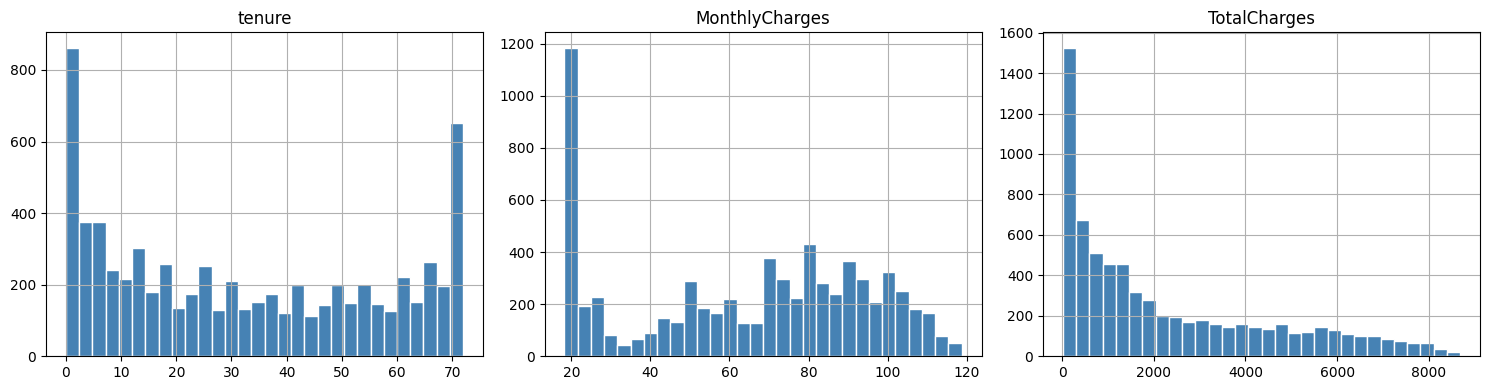

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['tenure', 'MonthlyCharges', 'TotalCharges']):
    df[col].hist(bins=30, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(col)
plt.tight_layout()
plt.show()

1. Tenure: Bimodal graph
2. MonthlyCharges: Not entirely right skewed but it spikes at lower end.
3. TotalCharges: Its right skewed, because its derived from the combination of the factors: tenure and monthly charges.

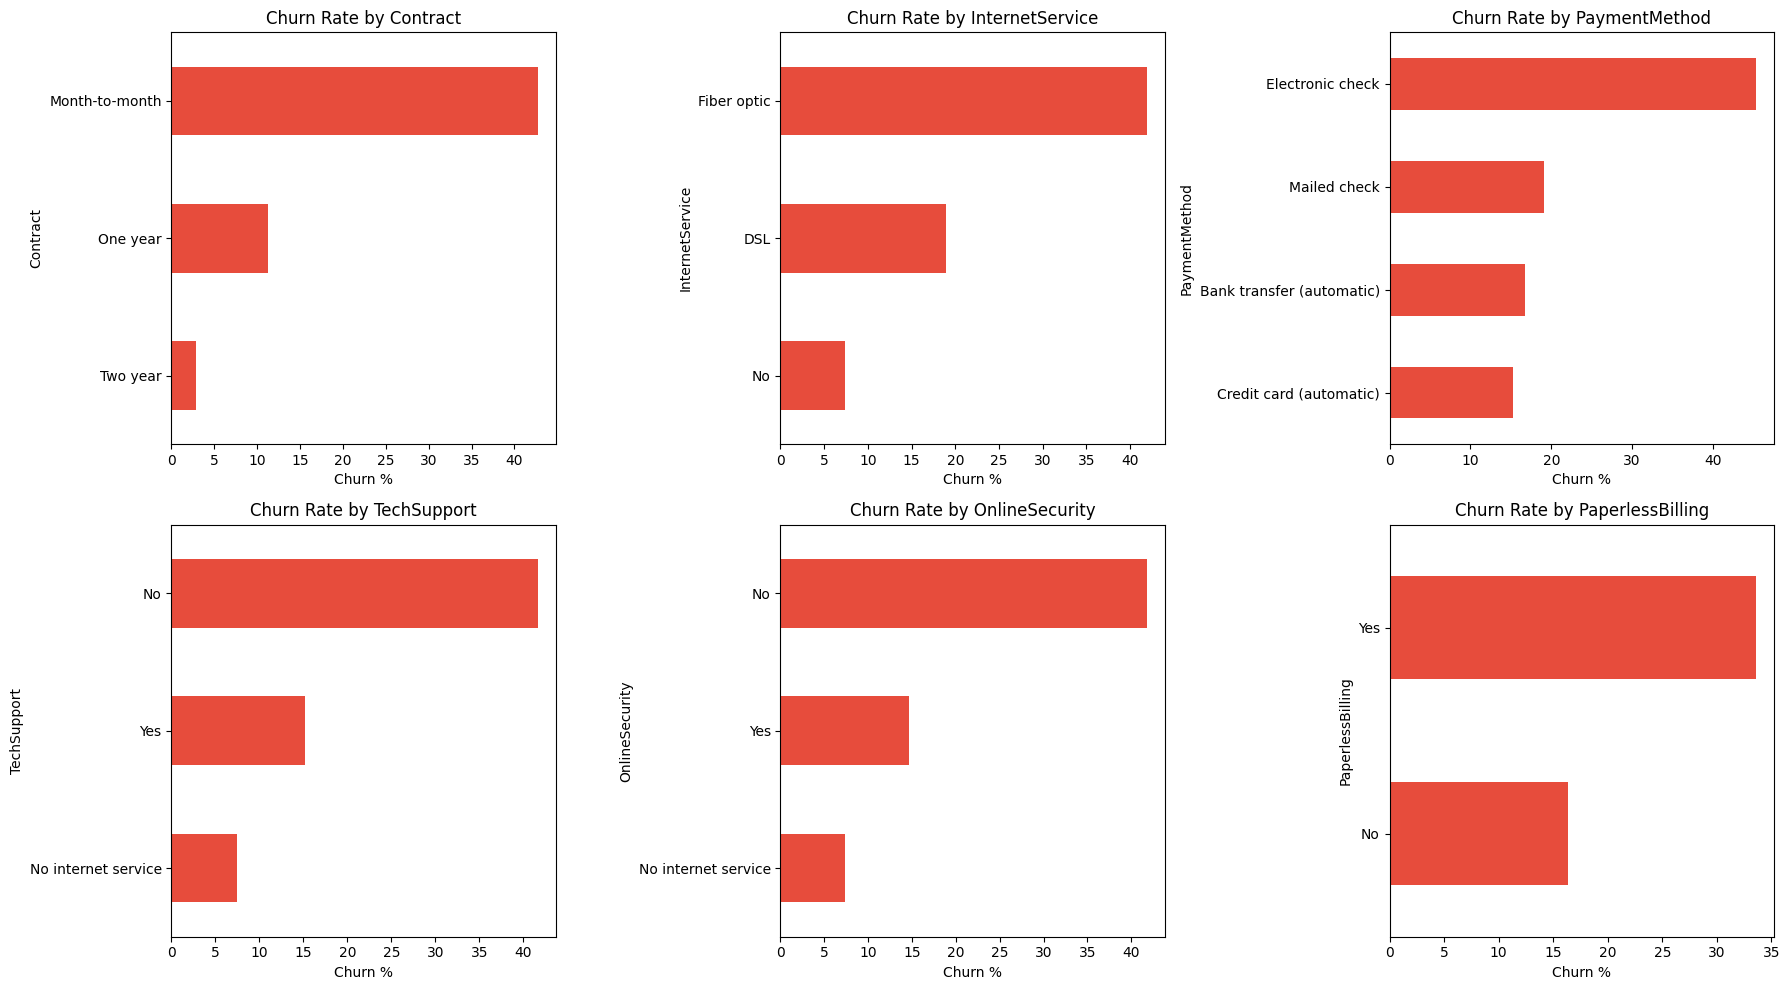

In [11]:
cat_features = ['Contract', 'InternetService', 'PaymentMethod',
                'TechSupport', 'OnlineSecurity', 'PaperlessBilling']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, col in zip(axes.flatten(), cat_features):
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
    churn_rate.sort_values().plot(kind='barh', ax=ax, color='#e74c3c')
    ax.set_title(f"Churn Rate by {col}")
    ax.set_xlabel("Churn %")
plt.tight_layout()
plt.show()

1. At first the churn rates in case of no internet connection felt kinda counter-intuitive to me, but after some searches and prompts it makes sense that when there is less internet connection and more landline, the failure points reduce hence the less churn rate, and a major reason also contributes to the use by senior citizens.

2. But in the case of paperless billing, it seems that they get burried under the promotions tab in gmails, and they say that the paper one stays on your countertop, make it a tangible evidence of ur usage. Its also the case that those who use paperless billing, are looking out for competative services, and if it is available at lower prices they shift.

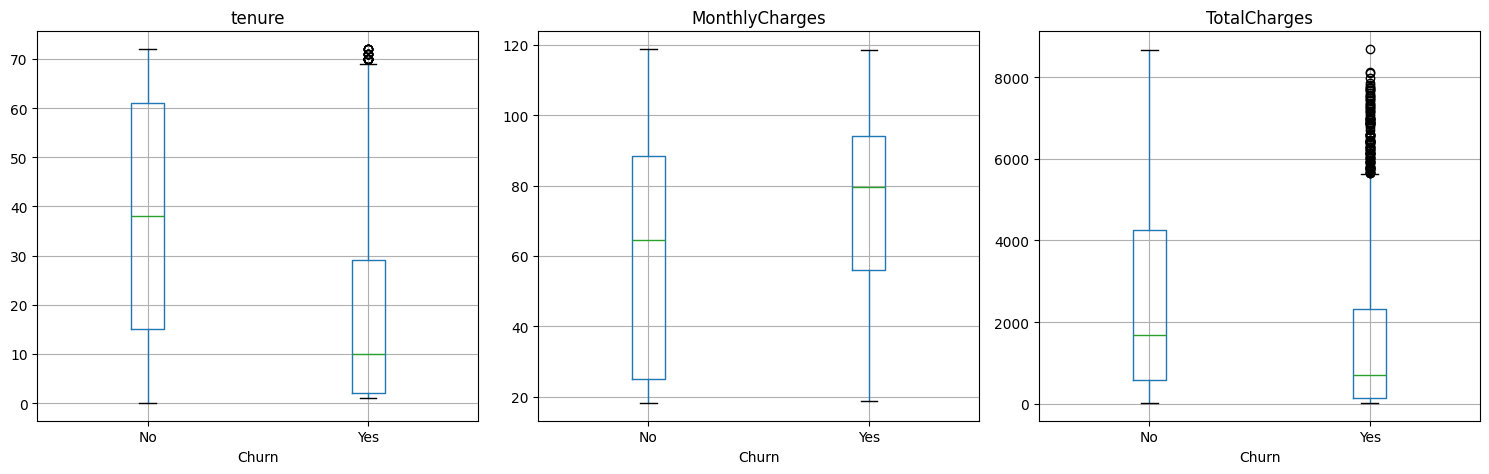

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, ['tenure', 'MonthlyCharges', 'TotalCharges']):
    df.boxplot(column=col, by='Churn', ax=ax)
    ax.set_title(col)
plt.suptitle("")
plt.tight_layout()
plt.show()

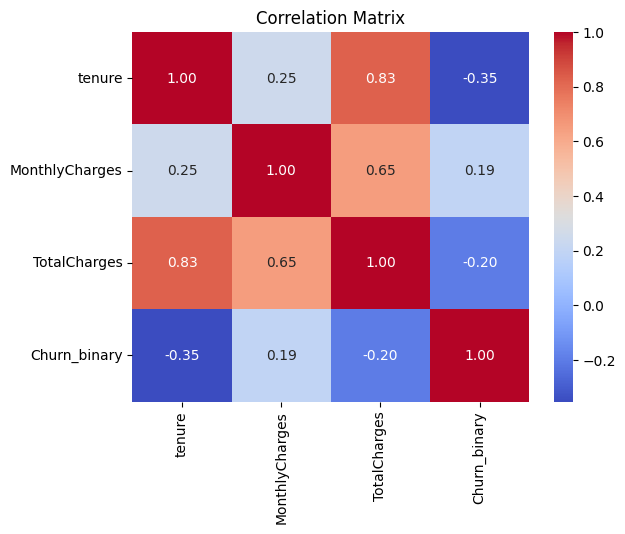

In [13]:
# Encode Churn as binary for correlation
df['Churn_binary'] = (df['Churn'] == 'Yes').astype(int)

corr = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_binary']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix")
plt.show()

In [14]:
print(df.isnull().sum()[df.isnull().sum() > 0])

TotalCharges    11
dtype: int64


#**PHASE2**: Preprocessing **Pipeline**

In [15]:
df = df.drop(columns=['customerID'])

df['TotalCharges']=pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges']=df['TotalCharges'].fillna(0)

df['Churn'] = (df['Churn'] == 'Yes').astype(int)

1. We apply **.fillna** to the **TotalCharges** column because the earlier operation in place of returning `ValueError` returns `NaN`, so we fill those `NaN` value with 0.

2. We also know that the **Churn** column has `yes/no` dtype so we convert it into `1/0`.

In [16]:
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

binary_features = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'SeniorCitizen']

multi_cat_features = ['MultipleLines', 'InternetService', 'OnlineSecurity',
                      'OnlineBackup', 'DeviceProtection', 'TechSupport',
                      'StreamingTV', 'StreamingMovies', 'Contract',
                      'PaymentMethod']

In [17]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer

numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

binary_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy="most_frequent")),
    ('encoder', OneHotEncoder(drop='if_binary', sparse_output=False))
])

multi_cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocesser = ColumnTransformer(transformers=[
    ('num', numerical_transformer, numerical_features),
    ('bin', binary_transformer, binary_features),
    ('cat', multi_cat_transformer, multi_cat_features)
])


`sparse_output=False` it tells the computer to return the a standard, easy to read NumPy array.

In [18]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

We use `stratify=y` so that the test set also behaves same as the original set

In [19]:
X_train_processed = preprocesser.fit_transform(X_train)
X_test_processed = preprocesser.fit_transform(X_test)

print("Train shape: ", X_train_processed.shape)
print("Test shape: ", X_test_processed.shape)

Train shape:  (5634, 40)
Test shape:  (1409, 40)


In [20]:
# Verify no nulls survived
print("Nulls in train:", np.isnan(X_train_processed).sum())
print("Nulls in test:", np.isnan(X_test_processed).sum())

# Check class balance in splits
print("Train churn rate:", y_train.mean().round(3))
print("Test churn rate:", y_test.mean().round(3))
# Both should be ~0.265

Nulls in train: 0
Nulls in test: 0
Train churn rate: 0.265
Test churn rate: 0.265


#**PHASE 4:** Baseline **Models**

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

In [22]:
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocesser),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocesser),
    ('model', DecisionTreeClassifier(random_state=42))
])

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocesser),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])

In [23]:
lr_pipeline.fit(X_train, y_train)
dt_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('bin',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='if_binary',
                                                                                 sparse_output=False))]),
                                                  ['g...
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaymentMethod'])])),
                ('model', RandomForestClassifier(random_state=42))])

In [24]:
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

models = {
    'Logistic Regression': lr_pipeline,
    'Decision Tree': dt_pipeline,
    'Random Forest': rf_pipeline
}

for name, pipeline in models.items():
  y_pred = pipeline.predict(X_test)
  y_prob = pipeline.predict_proba(X_test)[:,1]

  print(f"\n{'='*40}")
  print(f"{name}")
  print(f"{'='*40}")
  print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))
  print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")



Logistic Regression
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

ROC-AUC: 0.8420

Decision Tree
              precision    recall  f1-score   support

    No Churn       0.81      0.80      0.81      1035
       Churn       0.47      0.49      0.48       374

    accuracy                           0.72      1409
   macro avg       0.64      0.65      0.64      1409
weighted avg       0.72      0.72      0.72      1409

ROC-AUC: 0.6466

Random Forest
              precision    recall  f1-score   support

    No Churn       0.83      0.89      0.86      1035
       Churn       0.62      0.49      0.55       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70  

1. The **ROC-AUC** score is a performance metric used primarily in binary classification to evaluate how well a model can distinguish between two classes (e.g., "Spam" vs. "Not Spam").

2. **Precision** is the measure of quality or exactness.

3. The **F1-Score** is the "middle ground" metric. It is the `harmonic mean of Precision and Recall`, designed to give you a single number that balances both.
It is particularly useful when you have an `imbalanced dataset` (where one class is much more frequent than the other) and you need a balance between avoiding false alarms (Precision) and catching all positives (Recall).

4. **Support** represents the actual `number of occurrences` of each class in your dataset.

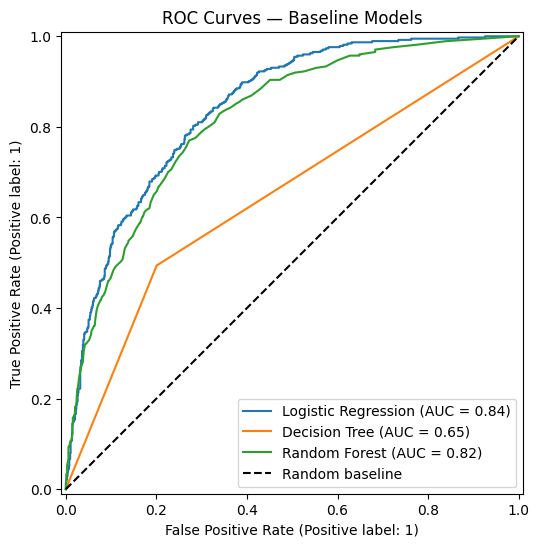

In [25]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize = (8,6))

for name, pipeline in models.items():
  RocCurveDisplay.from_estimator(pipeline, X_test, y_test, ax=ax, name=name)

ax.plot([0, 1], [0, 1], 'k--', label='Random baseline')
ax.set_title("ROC Curves — Baseline Models")
plt.legend()
plt.show()

1. In this graph the `Y-axis` represents the cases that we actually catched as correct out of all the actual positive cases.

2. `X-axis` represents all the cases that we caught as correct wrong given that they were actually false.

3. We can interpret from the graph that:
    1. The data has a strong linear relationship.
    2. Decision tree(orange line) are the worst performers, most likely due to overfitting or they are too shallow.
    3. Random Forests lie in the between them.

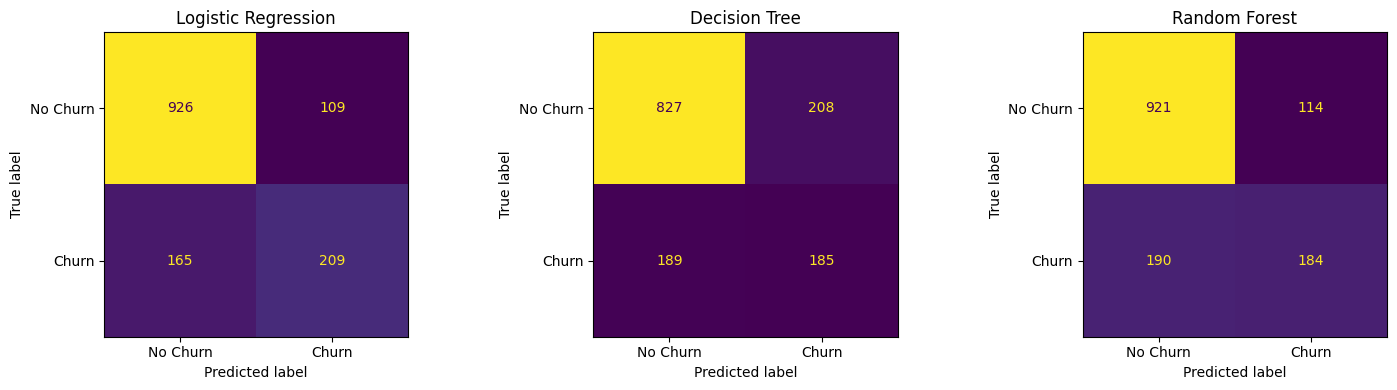

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, pipeline) in zip(axes, models.items()):
    ConfusionMatrixDisplay.from_estimator(
        pipeline, X_test, y_test,
        display_labels=['No Churn', 'Churn'],
        ax=ax, colorbar=False
    )
    ax.set_title(name)

plt.tight_layout()
plt.show()

#**PHASE 4:** Handling Class **Imbalance**

We will use **2** approaches to handle for the class imbalance and then **compare** it with the Phase 3 **baselines**.

1. `class_weight` method

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

lr_balanced = Pipeline(steps=[
    ('preprocessor', preprocesser),
    ('model', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
])

rf_balanced = Pipeline(steps=[
    ('preprocessor', preprocesser),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'))
])

lr_balanced.fit(X_train, y_train)
rf_balanced.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('bin',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='if_binary',
                                                                                 sparse_output=False))]),
                                                  ['g...
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaymentMethod'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=42))])

2. `smote` method

Synthetic Minority Oversampling Technique. Generates synthetic churner samples by interpolating between existing minority class points in feature space. Applied only on training data — never touch the test set.

In [28]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Note: We use imblearn's Pipeline, not sklearn's as the earlier one handles resampling correctly
lr_smote = ImbPipeline(steps=[
    ('preprocessor', preprocesser),
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

rf_smote = ImbPipeline(steps=[
    ('preprocessor', preprocesser),
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])

lr_smote.fit(X_train, y_train)
rf_smote.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('bin',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='if_binary',
                                                                                 sparse_output=False))]),
                                                  ['g...
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaymentMethod'])])),
                ('smote', SMOTE(random_state=42)),
                ('model', RandomForestClassifier(random_state=42))])

In [29]:
from sklearn.metrics import classification_report, roc_auc_score

models_p4 = {
    'LR + class_weight': lr_balanced,
    'RF + class_weight': rf_balanced,
    'LR + SMOTE': lr_smote,
    'RF + SMOTE': rf_smote
}

for name, pipeline in models_p4.items():
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    print(f"\n{'='*40}")
    print(f"{name}")
    print(f"{'='*40}")
    print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))
    print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")


LR + class_weight
              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

ROC-AUC: 0.8415

RF + class_weight
              precision    recall  f1-score   support

    No Churn       0.82      0.89      0.85      1035
       Churn       0.60      0.47      0.53       374

    accuracy                           0.78      1409
   macro avg       0.71      0.68      0.69      1409
weighted avg       0.76      0.78      0.77      1409

ROC-AUC: 0.8153

LR + SMOTE
              precision    recall  f1-score   support

    No Churn       0.91      0.71      0.80      1035
       Churn       0.50      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.70      0.76      0.71   

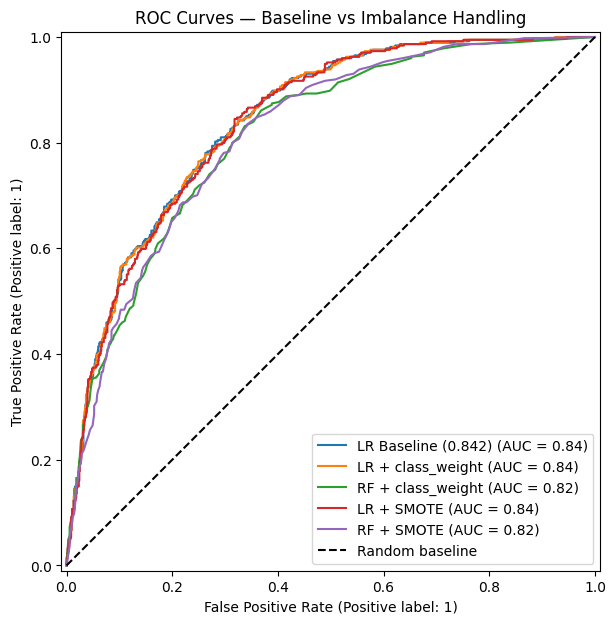

In [30]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 7))

# Phase 3 best (LR baseline)
RocCurveDisplay.from_estimator(lr_pipeline, X_test, y_test, ax=ax, name='LR Baseline (0.842)')

# Phase 4 models
for name, pipeline in models_p4.items():
    RocCurveDisplay.from_estimator(pipeline, X_test, y_test, ax=ax, name=name)

ax.plot([0, 1], [0, 1], 'k--', label='Random baseline')
ax.set_title("ROC Curves — Baseline vs Imbalance Handling")
plt.legend(loc='lower right')
plt.show()

1. **LR + SMOTE** hits `0.80` churn recall up from `0.56`.
2. **ROC-AUC** barely moved across all LR variants — the discrimination ability was already there, `imbalance handling just shifted the decision threshold effectively`
3. Precision dropped from `0.66 → 0.50`; the tradeoff is real but acceptable for a churn use case.
4. RF variants barely benefited; Random Forest has its own internal bootstrapping that partially handles imbalance already, so SMOTE adds less value.

#**PHASE 4:** Gradient **Boost** and **Hyperparameter** Tuning

In [31]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import RandomizedSearchCV
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import numpy as np

In [33]:
lgbm_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocesser),
    ('smote', SMOTE(random_state=42)),
    ('model', LGBMClassifier(random_state=42, verbose = -1))
])

The `verbose` parameter controls the level of detail the model provides about its internal processes while it is training.

In [35]:
param_dist = {
    'model__n_estimators': [100, 200, 300, 500],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'model__max_depth': [3, 5, 7, -1],
    'model__num_leaves': [20, 31, 50, 70],
    'model__min_child_samples': [10, 20, 30],
    'model__subsample': [0.7, 0.8, 1.0],
    'model__colsample_bytree': [0.7, 0.8, 1.0],
    'model__scale_pos_weight': [1, 2, 3]  # another lever for imbalance
}

search = RandomizedSearchCV(
    lgbm_pipeline,
    param_distributions = param_dist,
    scoring = 'roc_auc',
    cv=5,
    random_state=42,
    n_jobs = 1,
    verbose=1
)

search.fit(X_train, y_train)
print("Best Params: ", search.best_params_)
print("Best CV AUC: ", search.best_score_.round(4))

Fitting 5 folds for each of 10 candidates, totalling 50 fits


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

Best Params:  {'model__subsample': 1.0, 'model__scale_pos_weight': 1, 'model__num_leaves': 20, 'model__n_estimators': 100, 'model__min_child_samples': 10, 'model__max_depth': -1, 'model__learning_rate': 0.05, 'model__colsample_bytree': 1.0}
Best CV AUC:  0.8447


`RandomizedSearchCV`: Instead of manually changing hyperparameters (like learning rate or tree depth) and re-running the code dozens of times, this function does it on its own. It picks combinations at random, tests them, and tells which one performed the best.
1. CV->Cross Validation

In [36]:
from sklearn.metrics import classification_report, roc_auc_score

best_model = search.best_estimator_

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

              precision    recall  f1-score   support

    No Churn       0.86      0.82      0.84      1035
       Churn       0.57      0.64      0.60       374

    accuracy                           0.78      1409
   macro avg       0.72      0.73      0.72      1409
weighted avg       0.79      0.78      0.78      1409

ROC-AUC: 0.8428


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


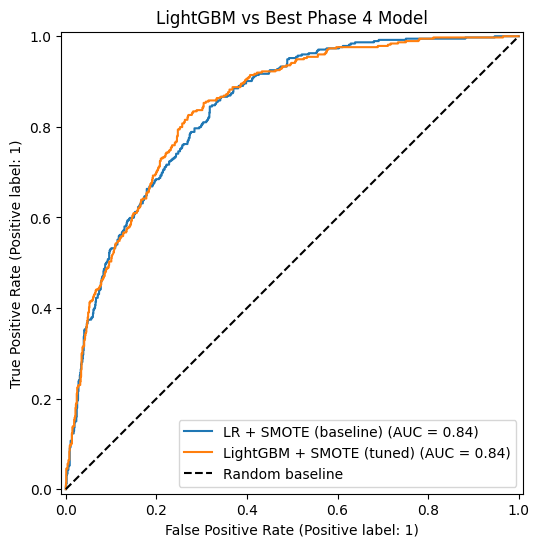

In [37]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_estimator(lr_smote, X_test, y_test, ax=ax, name='LR + SMOTE (baseline)')
RocCurveDisplay.from_estimator(best_model, X_test, y_test, ax=ax, name='LightGBM + SMOTE (tuned)')
ax.plot([0, 1], [0, 1], 'k--', label='Random baseline')
ax.set_title("LightGBM vs Best Phase 4 Model")
plt.legend()
plt.show()

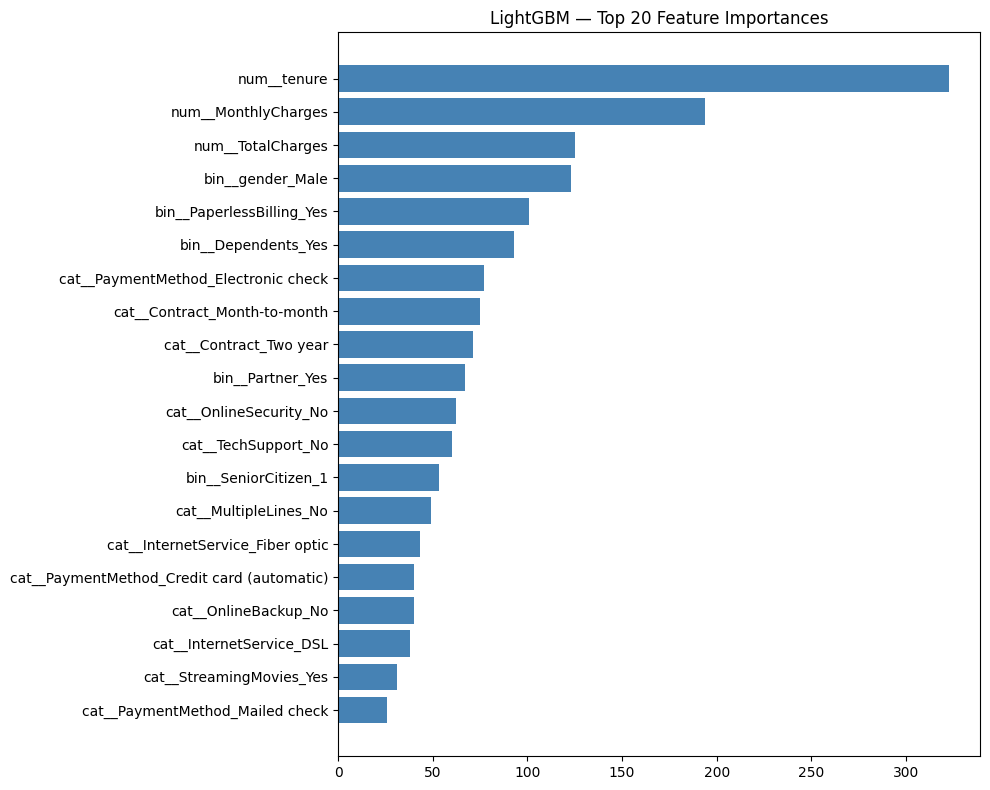

In [38]:
import matplotlib.pyplot as plt

# Extract the fitted LightGBM model from the pipeline
fitted_lgbm = best_model.named_steps['model']

# Get feature names after preprocessing
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()

# Plot top 20
importances = fitted_lgbm.feature_importances_
indices = np.argsort(importances)[-20:]

plt.figure(figsize=(10, 8))
plt.barh(range(len(indices)), importances[indices], color='steelblue')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.title("LightGBM — Top 20 Feature Importances")
plt.tight_layout()
plt.show()